# 😴 Driver Drowsiness Detection — Eye State Classification (CNN)

A CNN that classifies a cropped eye image as **Open** or **Closed**, as the core signal for a driver-drowsiness alert system (repeated "closed" predictions over time would trigger an alert in a full system).

**Dataset:** MRL Eye Dataset (via Kaggle, `mrl-dataset`) — grayscale 64×64 eye crops, labeled `Open_Eyes` / `Closed_Eyes`.

**Model:** a compact CNN (2 conv blocks with BatchNorm + MaxPooling + Dropout, then dense layers), trained with a `ModelCheckpoint` callback that keeps the best weights by validation loss.

**Result:** ~99.9% test accuracy (see the evaluation cell near the end) — the confusion matrix at the bottom shows there's essentially no confusion between the two classes on the held-out test set.

In [1]:
import numpy as np 
import pandas as pd 
import os
import tensorflow as tf

from glob import glob
from tqdm import tqdm

import matplotlib.pyplot as plt
from PIL import Image

In [2]:
X = []
Y = []

for i in tqdm(glob('/kaggle/input/mrl-dataset/train/Open_Eyes/*')):
    temp = np.array(Image.open(i).resize((64,64)))
    X.append(temp)
    Y.append(1)
    
for i in tqdm(glob('/kaggle/input/mrl-dataset/train/Closed_Eyes/*')):
    temp = np.array(Image.open(i).resize((64,64)))
    X.append(temp)
    Y.append(0)    

0it [00:00, ?it/s]
0it [00:00, ?it/s]


In [3]:
X = np.array(X)
X = X/255.0
Y = np.array(Y)

In [5]:
X.shape

(4000, 64, 64)

In [6]:
X = np.expand_dims(X,-1)

In [7]:
X.shape

(4000, 64, 64, 1)

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, BatchNormalization, MaxPooling2D,Dropout, Flatten


In [10]:
model = tf.keras.models.Sequential([
      Input(shape=(64, 64, 1)),

      Conv2D(filters = 32, kernel_size = 5, strides = 1, activation = 'relu'),
      Conv2D(filters = 32, kernel_size = 5, strides = 1, activation = 'relu', use_bias=False),
      BatchNormalization(),
      MaxPooling2D(strides = 2),
      Dropout(0.3),

      Conv2D(filters = 64, kernel_size = 3, strides = 1, activation = 'relu'),
      Conv2D(filters = 64, kernel_size = 3, strides = 1, activation = 'relu', use_bias=False),
      BatchNormalization(),
      MaxPooling2D(strides = 2),
      Dropout(0.3),

      Flatten(),
      Dense(units  = 256, activation = 'relu', use_bias=False),
      BatchNormalization(),

      Dense(units = 128, use_bias=False, activation = 'relu'),

      Dense(units = 84, use_bias=False, activation = 'relu'),
      BatchNormalization(),
      Dropout(0.3),

      Dense(units = 1, activation = 'sigmoid')
  ])

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [12]:
callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='bestModel.h5',
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose =1)
model.fit(x_train, y_train, validation_split=0.2, epochs=30, batch_size=32, callbacks=callback)

Epoch 1/30


2023-10-29 11:30:03.227576: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


66/67 [============================>.] - ETA: 0s - loss: 0.1233 - accuracy: 0.9555

Epoch 1: val_loss improved from inf to 1.06794, saving model to bestModel.h5

67/67 [==============================] - 12s 18ms/step - loss: 0.1233 - accuracy: 0.9557 - val_loss: 1.0679 - val_accuracy: 0.5187

Epoch 2/30

67/67 [==============================] - ETA: 0s - loss: 0.0390 - accuracy: 0.9869

Epoch 2: val_loss did not improve from 1.06794

67/67 [==============================] - 1s 10ms/step - loss: 0.0390 - accuracy: 0.9869 - val_loss: 1.1331 - val_accuracy: 0.5317

Epoch 3/30

67/67 [==============================] - ETA: 0s - loss: 0.0435 - accuracy: 0.9860

Epoch 3: val_loss improved from 1.06794 to 0.60534, saving model to bestModel.h5

67/67 [==============================] - 1s 12ms/step - loss: 0.0435 - accuracy: 0.9860 - val_loss: 0.6053 - val_accuracy: 0.6679

Epoch 4/30

67/67 [==============================] - ETA: 0s - loss: 0.0187 - accuracy: 0.9963

Epoch 4: val_loss did not 

In [13]:
model.evaluate(x_test, y_test)

42/42 [==============================] - 0s 5ms/step - loss: 0.0010 - accuracy: 0.9992


[0.001017295871861279, 0.9992424249649048]

In [14]:
from keras.models import load_model
best_model = load_model('/kaggle/working/bestModel.h5')
best_model.evaluate(x_test, y_test)

42/42 [==============================] - 0s 3ms/step - loss: 0.0021 - accuracy: 0.9992


[0.0020967486780136824, 0.9992424249649048]

1/1 [==============================] - 0s 213ms/step


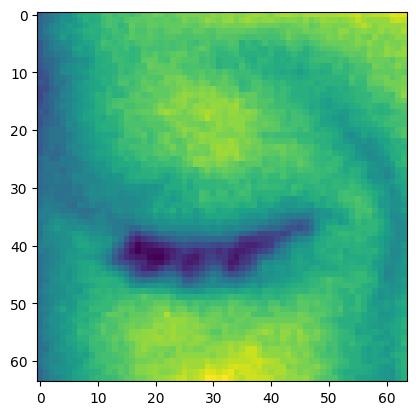

Closed

1/1 [==============================] - 0s 19ms/step


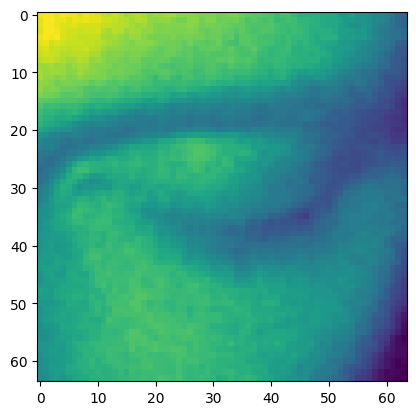

Closed

1/1 [==============================] - 0s 19ms/step


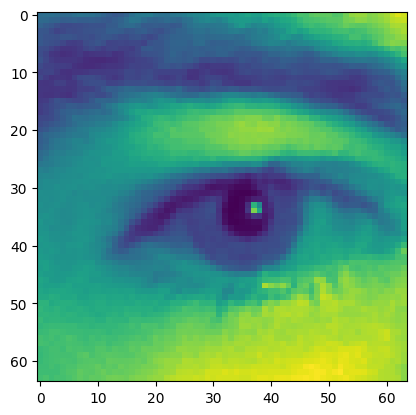

Open

1/1 [==============================] - 0s 18ms/step


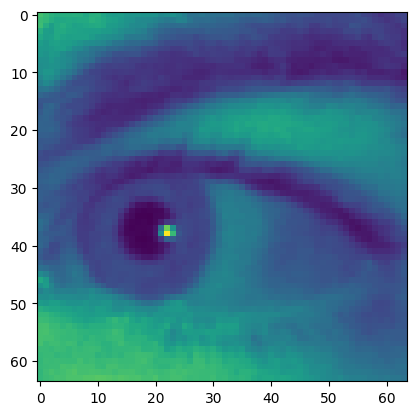

Open

1/1 [==============================] - 0s 18ms/step


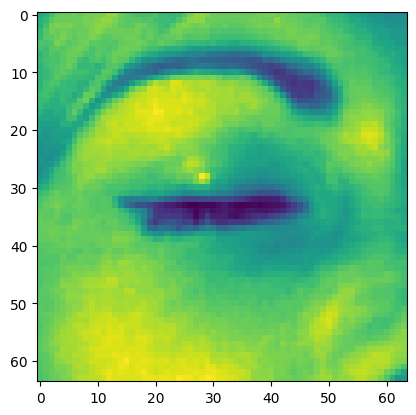

Closed


In [15]:
for i in x_test[10:15]:
    result = best_model.predict(np.expand_dims(i,0))
    plt.imshow(i)
    plt.show()
    
    if result > 0.5:
        print('Open')
    else:
        print("Closed")

42/42 [==============================] - 0s 2ms/step


Text(0.5, 25.722222222222214, 'Actual')

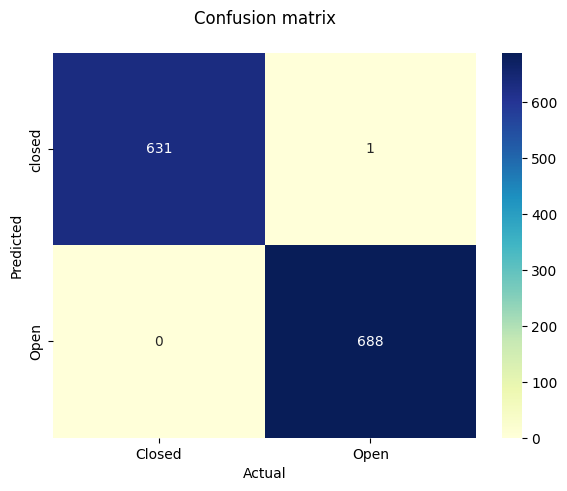

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(15, 5))

preds = best_model.predict(x_test)
preds = (preds >= 0.5).astype(np.int32)
cm = confusion_matrix(y_test, preds)
df_cm = pd.DataFrame(cm, index=['closed', 'Open'], columns=['Closed', 'Open'])
plt.subplot(121)
plt.title("Confusion matrix\n")
sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu")
plt.ylabel("Predicted")
plt.xlabel("Actual")